# Day 7: Session 7B - Name the Columns, Not the Colours

[Session Webpage](https://eds-217-essential-python.github.io/course-materials/interactive-sessions/7b_seaborn.html)

Date: 09/09/2026

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = 'https://eds-217-essential-python.github.io/data/messy_field_survey.csv'
survey = pd.read_csv(url)

survey = survey.drop_duplicates()

survey['site'] = survey['site'].str.strip()
survey['site'] = survey['site'].str.lower()
survey['site'] = survey['site'].str.replace('-', '_')

survey['pH'] = survey['pH'].str.replace(',', '.')
survey['pH'] = survey['pH'].astype(float)

survey = survey.dropna(subset=['temperature_c', 'dissolved_oxygen_mg_L', 'conductivity_uS_cm'])
survey['n_replicates'] = survey['n_replicates'].fillna(1)
survey['n_replicates'] = survey['n_replicates'].astype(int)

survey = survey[survey['temperature_c'] > -100].copy()
survey = survey.rename(columns={'collection date': 'collection_date'})

survey.shape

(255, 7)

### The same figure, made two ways

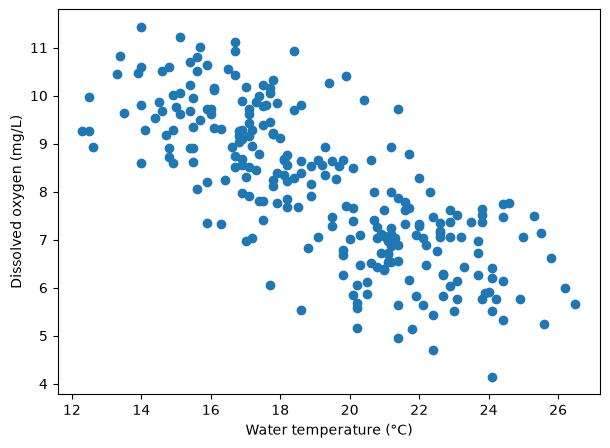

In [2]:
plt.figure(figsize=(7, 5))

plt.scatter(survey['temperature_c'], survey['dissolved_oxygen_mg_L'])

plt.xlabel('Water temperature (°C)')
plt.ylabel('Dissolved oxygen (mg/L)')
plt.show()

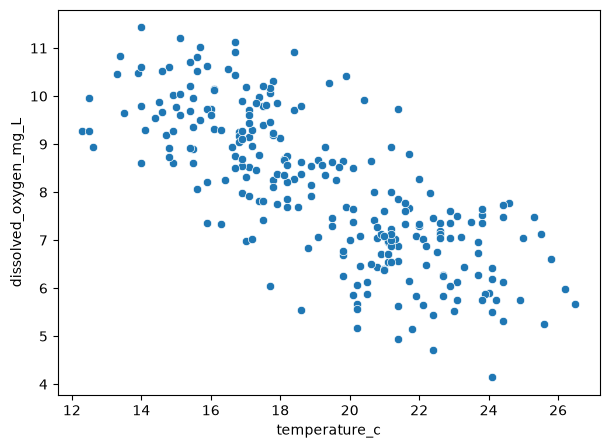

In [3]:
# same fig as above, but made using seaborn

plt.figure(figsize=(7, 5))

sns.scatterplot(data=survey, x='temperature_c', y='dissolved_oxygen_mg_L')

plt.show()

### seaborn scatterplot format

    sns.scatterplot(data=df, x='column_name', y='column_name')

                      ↑        ↑                ↑
                the table | column across | column up

### hue=, and what a table cannot show you



In [4]:
print(survey.groupby('site')['dissolved_oxygen_mg_L'].mean().sort_values())
print(survey.groupby('site')['temperature_c'].mean().sort_values())

site
site_f     6.180233
site_c     6.873111
site_e     7.410930
site_b     8.601220
site_a     9.485909
site_d    10.053333
Name: dissolved_oxygen_mg_L, dtype: float64
site
site_d    15.179487
site_a    16.600000
site_b    18.102439
site_e    19.730233
site_c    21.911111
site_f    23.297674
Name: temperature_c, dtype: float64


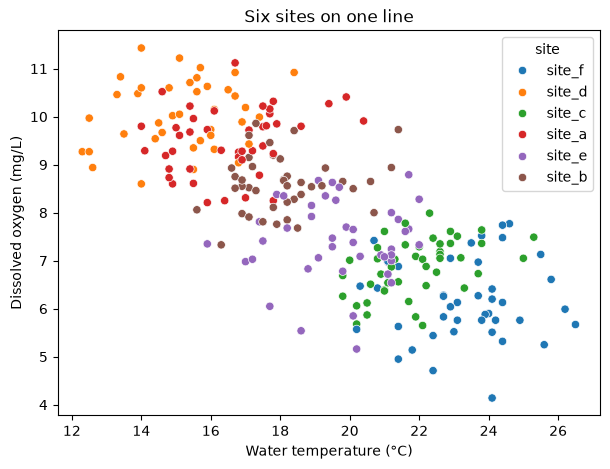

In [5]:
plt.figure(figsize=(7, 5))

sns.scatterplot(data=survey, x='temperature_c', y='dissolved_oxygen_mg_L', hue='site')

plt.xlabel('Water temperature (°C)')
plt.ylabel('Dissolved oxygen (mg/L)')
plt.title('Six sites on one line')
plt.show()

hue= takes a column name and gives every distinct value in that column its own colour

### Test your knowledge
Write a seaborn scatter plot of conductivity_uS_cm against dissolved_oxygen_mg_L, coloured by site, inside a figure eight inches by five. Label both axes with units and give it a title.

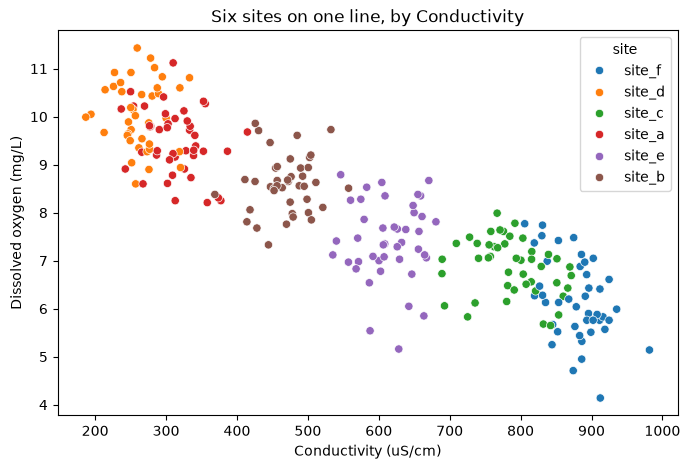

In [ ]:


# based on this figure, the sites separate more cleanly by conductivity 
# than by temperature, telling us that conductivity varies more by site

### sns.histplot: the shape of one column


A scatter needs two variables. When you have one variable and want to know how its values are distributed, you want a histogram: the values sorted into bins, with a bar showing how many values are in each bin.


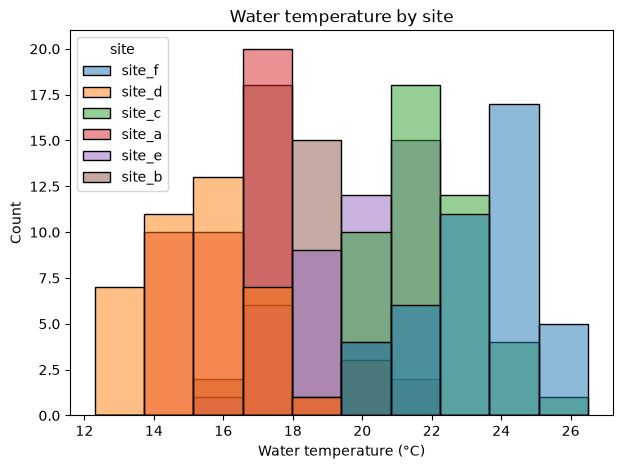

### Test your knowledge

Draw a histogram of pH, then draw it again with hue='site'. Label the axes.



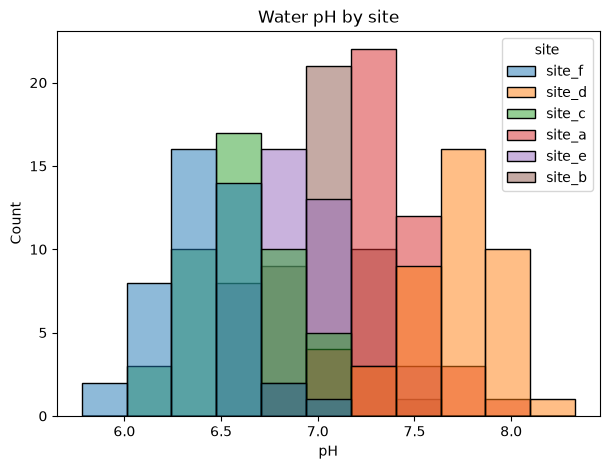

In [ ]:
, hu, 

### sns.barplot, and the Series idiom



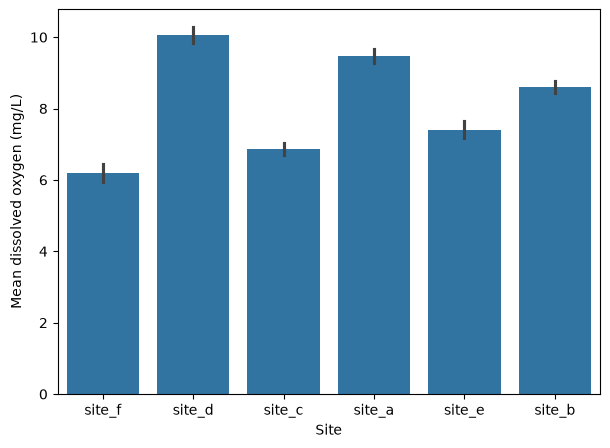

In [11]:
plt.figure(figsize=(7, 5))

sns.barplot(data=survey, x='site', y='dissolved_oxygen_mg_L')

plt.xlabel('Site')
plt.ylabel('Mean dissolved oxygen (mg/L)')
plt.show()

site
site_d    10.05
site_a     9.49
site_b     8.60
site_e     7.41
site_c     6.87
site_f     6.18
Name: dissolved_oxygen_mg_L, dtype: float64


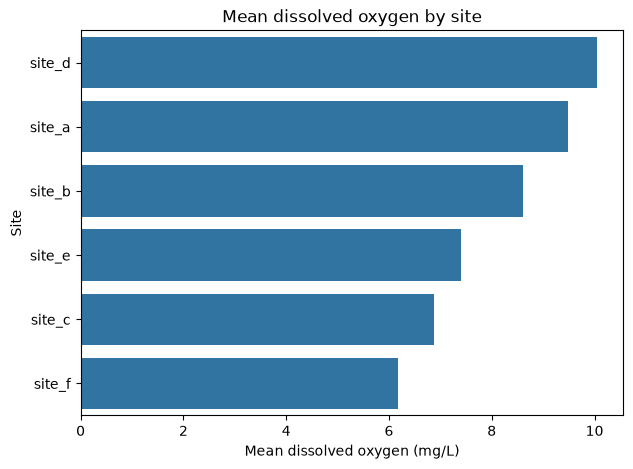

In [13]:
# the code in the previous cell groups implicitly, but with the downsides of
#  showing uncertainty even if not wanted, and the bars being in no
# particular order.  The alternative is to compute the numbers before plotting:

mean_do = survey.groupby('site')['dissolved_oxygen_mg_L'].mean().sort_values(ascending=False)

print(mean_do.round(2))

plt.figure(figsize=(7, 5))

sns.barplot(x=mean_do.values, y=mean_do.index)

plt.xlabel('Mean dissolved oxygen (mg/L)')
plt.ylabel('Site')
plt.title('Mean dissolved oxygen by site')
plt.show()

### format:

sns.barplot(x=series.values, y=series.index) ----> horizontal bars, sorted as you sorted them
sns.barplot(y=series.values, x=series.index) ----> vertical bars, same data


group, aggregate, sort, then plot the .values against the .index.

### Test your knowledge

Build a Series of mean conductivity_uS_cm by site, sorted from highest to lowest, and draw it as horizontal bars using the .values and .index idiom. Label both axes with units, give the figure a title, and end the cell with plt.tight_layout().



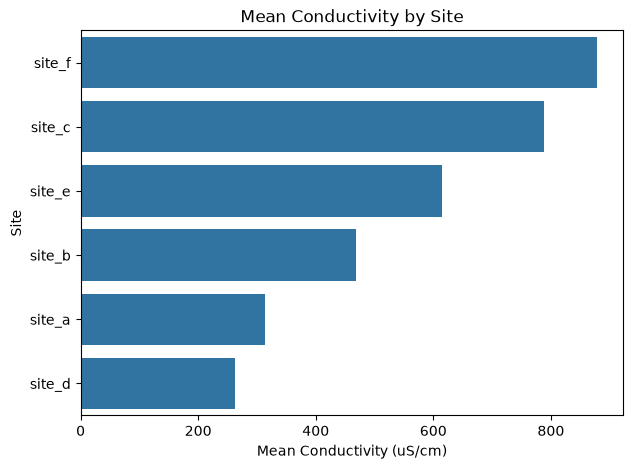

In [16]:
mean_cond = survey.groupby('site')['conductivity_uS_cm'].mean().sort_values(ascending=False)

plt.figure(figsize=(7, 5))

sns.barplot(x=mean_cond.values, y=mean_cond.index)

plt.xlabel('Mean Conductivity (uS/cm)')
plt.ylabel('Site')
plt.title('Mean Conductivity by Site')
plt.show()

### seaborn draws on matplotlib

seaborn draws onto a matplotlib axes. If none exists it makes one, exactly the way plt.plot() does

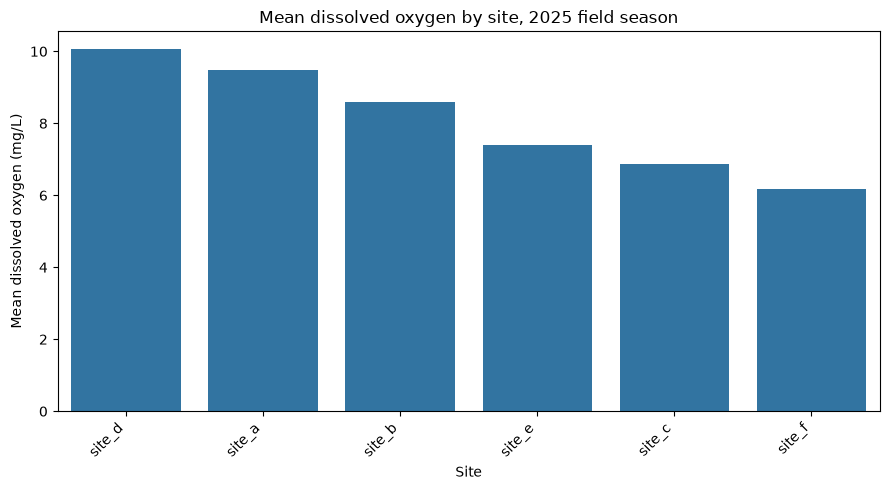

In [17]:
plt.figure(figsize=(9, 5))

sns.barplot(x=mean_do.index, y=mean_do.values)

plt.xlabel('Site')
plt.ylabel('Mean dissolved oxygen (mg/L)')
plt.title('Mean dissolved oxygen by site, 2025 field season')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Key points

- A seaborn call looks like sns.function(data=df, x='col', y='col'). The table goes in whole and the columns are named as strings.
- hue='col' splits any of these plots by a categorical column and builds the legend for you. It is the argument that answers does this relationship differ between groups?
- sns.scatterplot for one measurement against another.
- sns.histplot(data=, x=) for the distribution of a single column. No y=; the heights are counts.
- sns.barplot(data=, x='category', y='value') silently computes a mean and draws an uncertainty interval you did not ask for.
- Prefer the explicit route: .groupby(), aggregate, .sort_values(), then sns.barplot(x=series.values, y=series.index). You control the number and the order.
- seaborn draws on matplotlib, so plt.figure(figsize=), plt.xlabel(), plt.title(), plt.xticks(rotation=) and plt.tight_layout() all still work.
- A distribution that mixes groups looks wider than any group in it. Split it before you describe it.